In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt

# plotting modules
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
import seaborn as sns

# prediction module minimal set of code used in seasonal prediction
import prediction
# analysis module for all data exploration
import analysis

# READING DATA

In [11]:
# url="http://www.cpc.ncep.noaa.gov/data/indices/ersst5.nino.mth.91-20.ascii"
nino = prediction.read_nino()
# url="http://www.bom.gov.au/climate/enso/soi_monthly.txt"
soi = prediction.read_soi()
    
# TC data from historical counts
tcs = prediction.read_processed_tc(TC_folder='data/2021-22/')

# Just look at 3m mean july aug sep
nino_jas0 = nino[nino.index.month == 9].copy()['nino3.4 anom 3m mean']
soi_jas0 = soi[soi.index.month == 9].copy()['SOI 3m mean']

## Combined JAS data
data_jas0 = pd.merge(nino_jas, soi_jas, right_index=True, left_index=True, how='outer')
## Pre 1970 is poorly measured due to lack of geo-stationary satellite data
dt1970=dt.datetime(1970,1,1)
data_jas = data_jas0[dt1970:].copy()
nino_jas = nino_jas0[dt1970:].copy()
soi_jas = soi_jas0[dt1970:].copy()

In [3]:
data_jas.tail(3)

,nino3.4 anom 3m mean,SOI 3m mean
2019-09-01,0.140000,-7.466667
2020-09-01,-0.573333,8.166667
2021-09-01,-0.490000,9.933333


# Skill over time
- Skill is LEPS
- Rolling 20 year input space (to see skill over time)
- Each 20 year LEPS value is based on LOOCV: ie. mean LEPS using each year within the 20, one at a time, as the test year

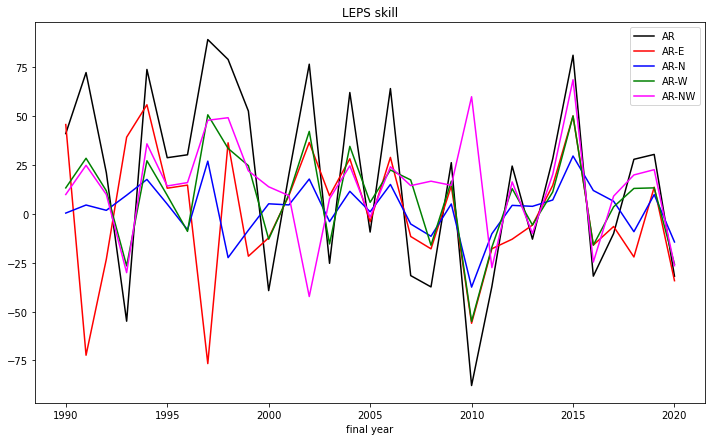

In [15]:

scores={}
plt.figure(figsize=[12,7])
for target,color in zip(['AR','AR-E','AR-N','AR-W','AR-NW'],['k','red','blue','green','magenta']):
    scores[target]={'endyear':[],'LEPS skill':[]}
    for endyear in range(1990,2021):
        dtEnd = dt.datetime(endyear,9,1)
        Y = tcs[target].copy()
        X1 = nino_jas[:dtEnd].copy()
        X2 = soi_jas[:dtEnd].copy()
        pred_nino, pred_soi = prediction.combo_method_SKL(X1,X2,Y,prediction_year=endyear)
        Y_pred = (pred_nino+pred_soi)/2.0
        Y_obs = (Y[dtEnd] > Y[:dt.datetime(endyear,4,1)].median())+1
        score = analysis.get_classification_scores(Y_pred,[Y_obs])
        
        scores[target]['endyear'].append(endyear)
        scores[target]['LEPS skill'].append(score['LEPS skill'])

    plt.plot(np.array(scores[target]['endyear']),np.array(scores[target]['LEPS skill'],),
             label=target, color=color)
plt.title("LEPS skill")
plt.xlabel('final year')
plt.legend()
plt.show()


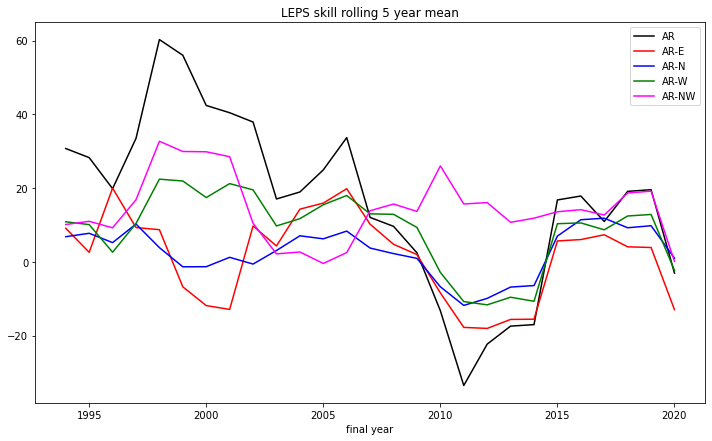

In [18]:
plt.figure(figsize=[12,7])
for target,color in zip(['AR','AR-E','AR-N','AR-W','AR-NW'],['k','red','blue','green','magenta']):
    # rolling mean
    dfi = pd.DataFrame(scores[target])
    # take rolling mean as new column (column index = 2, doesn't matter)
    dfi.insert(1,'rolling', dfi['LEPS skill'].rolling(window=5).mean(), allow_duplicates=True)
    plt.plot(np.array(dfi['endyear']),np.array(dfi['rolling'],),
             label=target, color=color)
plt.title("LEPS skill rolling 5 year mean")
plt.xlabel('final year')
plt.legend()
plt.show()

# TC vs Metrics

In [2]:
TC_bom = prediction.read_processed_tc()

In [3]:
print(len(TC_bom))
print(TC_bom[:3])
print(TC_bom[-4:])

52
            AR  AR-W  AR-NW  AR-N  AR-E  SPO  SPO-W  SPO-E
date                                                      
1969-09-01   5     2      2     2     3    8      5      4
1970-09-01  16    10      5     3     5    7      6      2
1971-09-01  15     5      4     3    10   16     12     11
            AR  AR-W  AR-NW  AR-N  AR-E  SPO  SPO-W  SPO-E
date                                                      
2017-09-01  10     7      6     4     2    7      4      4
2018-09-01  11     5      4     5     5   10      6      4
2019-09-01   9     5      4     2     2    5      3      2
2020-09-01   8     4      2     1     3   10      3      7


In [7]:
ds = xr.open_dataset("data/p_drivers_sst_s_m3_20220817_rt.nc")

In [10]:
print(ds.coords)
print(ds.time_counter.values)
#print(ds.ensemble_member)

Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2022-10-16T12:00:00 ... 2022-...
['2022-10-16T12:00:00.000000000' '2022-11-16T00:00:00.000000000'
 '2022-12-16T16:00:00.000000000']


In [13]:
nino = prediction.read_nino()

In [14]:
soi = prediction.read_soi()


In [19]:
nino.iloc[-1]

nino1+2                 20.680000
nino1+2 anom            -1.280000
nino3.4 anom 3m mean    -0.853333
nino3.4 3m mean         26.803333
nino4 anom 3m mean      -0.836667
nino4 3m mean           28.090000
nino3 anom 3m mean      -0.800000
nino3 3m mean           25.763333
nino1+2 anom 3m mean    -1.466667
nino1+2 3m mean         21.700000
nino3                   25.280000
nino3 anom              -0.530000
nino4                   27.920000
nino4 anom              -0.980000
nino3.4                 26.620000
nino3.4 anom            -0.680000
Name: 2022-07-01 00:00:00, dtype: float64

In [22]:
len(nino.loc[nino.index.year==2023])

0

In [ ]:
try:
    import cartopy
except ModuleNotFoundError:
    print("module 'cartopy' is not installed")
    print("DON'T CONTINUE")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

In [ ]:

## Projection and regions
# pacific crosses dateline
proj_pacific=ccrs.PlateCarree(central_longitude=180)
proj =ccrs.PlateCarree(central_longitude=0)
# regions [W,E,S,N]
view_extent = [60, -160, -50, 10]
AR = {"xy":[90,-40], "width":70, "height":35, "name":"AR"}
AR_W = {"xy":[90,-40], "width":35, "height":35, "name":"AR-W"}
AR_N = {"xy":[125,-40], "width":17.5, "height":35, "name":"AR-N"}
AR_E = {"xy":[142.5,-40], "width":17.5, "height":35, "name":"AR-E"}
AR_NW = {"xy":[105,-25], "width":25, "height":20, "name":"AR-NW"}

# set colour based on something?

## Draw plot on top of projection covering the pacific
plt.figure(figsize=[10,9])
ax = plt.subplot(1, 1, 1, projection=proj_pacific)
for reg in [AR,AR_W,AR_N,AR_E,AR_NW]:
    ax.add_patch(
        mpatches.Rectangle(
            #xy=[-70, -45], width=90, height=90,
            xy=reg["xy"], width=reg["width"], height=reg["height"],
            fill=False,
            transform=proj,
            #label=reg['name'],
            edgecolor='k',
            linestyle='--',
        )
    )

ax.gridlines(draw_labels=True, crs=proj)
# This doesn't seem to work well
ax.set_extent(view_extent, crs=proj_pacific)
ax.stock_img()
plt.show()